## EconAI — Conflict Risk Predictions

EconAI generates monthly country-level predictions of armed conflict. It produces four variables used in this project:

- `risk_3`: predicted probability of armed conflict onset in the next 3 months
- `risk_12`: predicted probability of armed conflict onset in the next 12 months
- `logfat_risk_3`: predicted fatalities in log scale at a 3-month horizon
- `logfat_risk_12`: predicted fatalities in log scale at a 12-month horizon

These variables are particularly valuable because they already embed conflict forecasting signal from an external model, making them strong candidate predictors for the early warning system. Unlike ACLED and IDMC which capture observed conflict, EconAI captures anticipated conflict risk,a more direct input for a predictive model.

In [1]:
import os
import pandas as pd
import numpy as np

df = pd.read_csv('../data_clean/final_data.csv')
print(f"Data loaded successfully: {df.shape}")

Data loaded successfully: (17424, 100)


In [2]:
# Descriptive statistics - EconAI variables
econai_cols = ['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12']

df[econai_cols].describe().round(3)

,risk_3,risk_12,logfat_risk_3,logfat_risk_12
count,17424.000,17424.000,17424.000,17424.000
mean,0.171,0.237,1.212,1.788
std,0.315,0.346,2.100,2.620
min,0.004,0.003,0.006,0.028
25%,0.006,0.011,0.008,0.049
50%,0.012,0.043,0.082,0.288
75%,0.105,0.301,1.374,2.809
max,1.000,1.000,9.763,10.689


In [3]:
# Missing values
print("Missing values:")
print(df[econai_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[econai_cols].isnull().sum() / len(df) * 100).round(2))

Missing values:
risk_3            0
risk_12           0
logfat_risk_3     0
logfat_risk_12    0
dtype: int64

Missing percentage:
risk_3            0.0
risk_12           0.0
logfat_risk_3     0.0
logfat_risk_12    0.0
dtype: float64


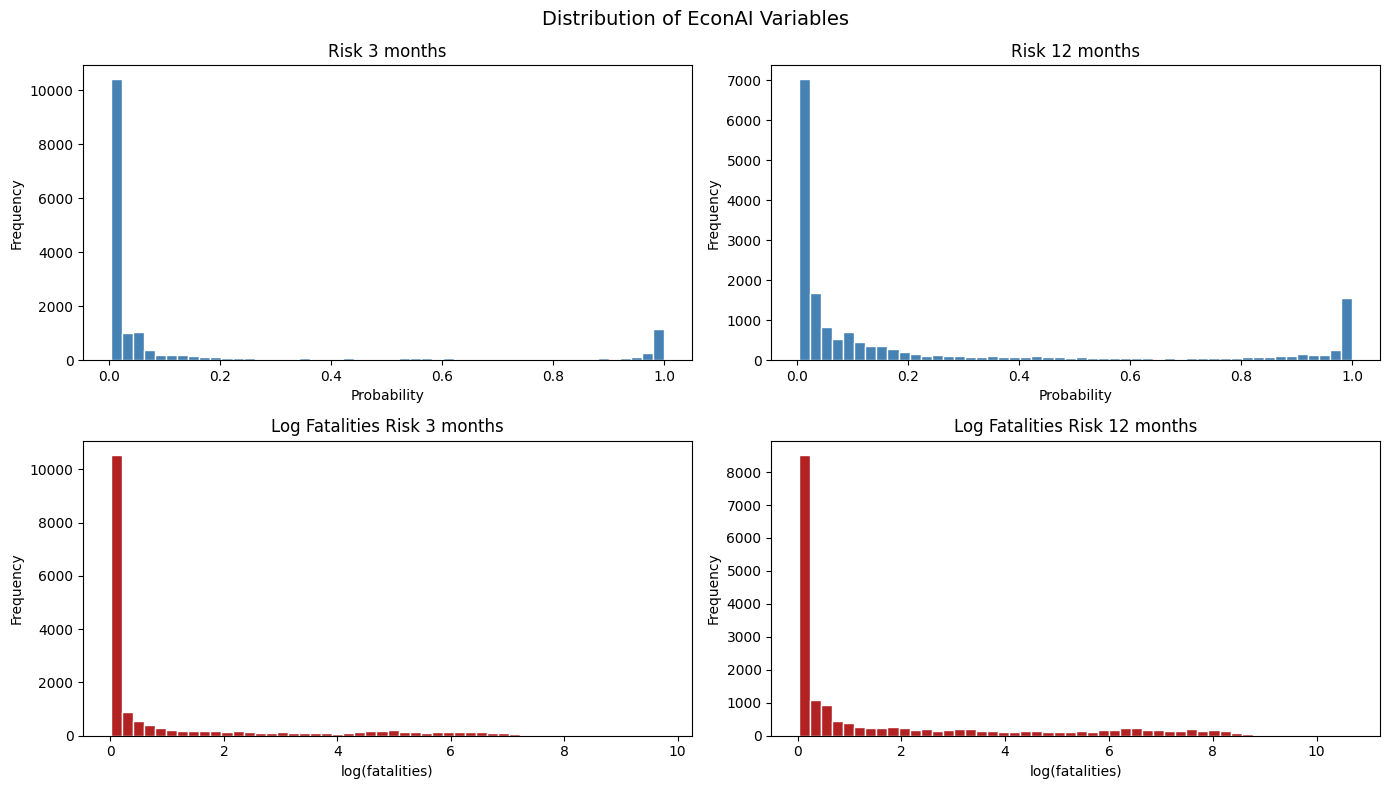

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of EconAI Variables', fontsize=14)

# risk_3
axes[0, 0].hist(df['risk_3'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Risk 3 months')
axes[0, 0].set_xlabel('Probability')
axes[0, 0].set_ylabel('Frequency')

# risk_12
axes[0, 1].hist(df['risk_12'], bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Risk 12 months')
axes[0, 1].set_xlabel('Probability')
axes[0, 1].set_ylabel('Frequency')

# logfat_risk_3
axes[1, 0].hist(df['logfat_risk_3'], bins=50, color='firebrick', edgecolor='white')
axes[1, 0].set_title('Log Fatalities Risk 3 months')
axes[1, 0].set_xlabel('log(fatalities)')
axes[1, 0].set_ylabel('Frequency')

# logfat_risk_12
axes[1, 1].hist(df['logfat_risk_12'], bins=50, color='firebrick', edgecolor='white')
axes[1, 1].set_title('Log Fatalities Risk 12 months')
axes[1, 1].set_xlabel('log(fatalities)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

All four EconAI variables show a strongly right-skewed distribution. For `risk_3` and `risk_12`, the majority of country-months receive very low conflict probabilities, concentrated near zero. However, both distributions show a notable secondary spike near 1.0, reflecting countries where EconAI assigns near-certainty of armed conflict typically chronic conflict contexts such as Afghanistan, Syria, or Yemen. `risk_12` shows a less extreme initial spike compared to `risk_3`, consistent with the descriptive statistics, at a 12-month horizon, the model assigns higher average probabilities since the accumulation window is longer. This is expected behavior for a conflict forecasting model.

The log fatality predictions follow a similar pattern , most country-months receive low predicted fatalities, with a long tail of high-risk observations. Neither variable contains missing values, confirming full coverage across the dataset.

In [6]:
# Top 10 countries by average risk_3, risk_12, logfat_risk_3, logfat_risk_12
econai_cols = ['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12']

for col in econai_cols:
    print(f"\n=== Top 10 Countries by avg {col} ===")
    print(df.groupby('iso3')[col].mean().nlargest(10).round(3))


=== Top 10 Countries by avg risk_3 ===
iso3
COD    0.995
MLI    0.992
SYR    0.989
CMR    0.987
YEM    0.983
CAF    0.969
SOM    0.968
NGA    0.954
MEX    0.949
BFA    0.920
Name: risk_3, dtype: float64

=== Top 10 Countries by avg risk_12 ===
iso3
MLI    0.997
SOM    0.997
COD    0.997
SYR    0.994
CMR    0.993
YEM    0.991
CAF    0.985
MEX    0.980
AFG    0.978
SDN    0.976
Name: risk_12, dtype: float64

=== Top 10 Countries by avg logfat_risk_3 ===
iso3
MEX    7.107
UKR    6.859
SYR    6.839
COD    6.706
AFG    6.696
NGA    6.596
YEM    6.440
SOM    6.390
ETH    6.082
MLI    5.869
Name: logfat_risk_3, dtype: float64

=== Top 10 Countries by avg logfat_risk_12 ===
iso3
MEX    8.483
SYR    8.276
AFG    8.213
COD    8.079
UKR    7.993
NGA    7.945
YEM    7.870
SOM    7.786
ETH    7.572
MLI    7.316
Name: logfat_risk_12, dtype: float64


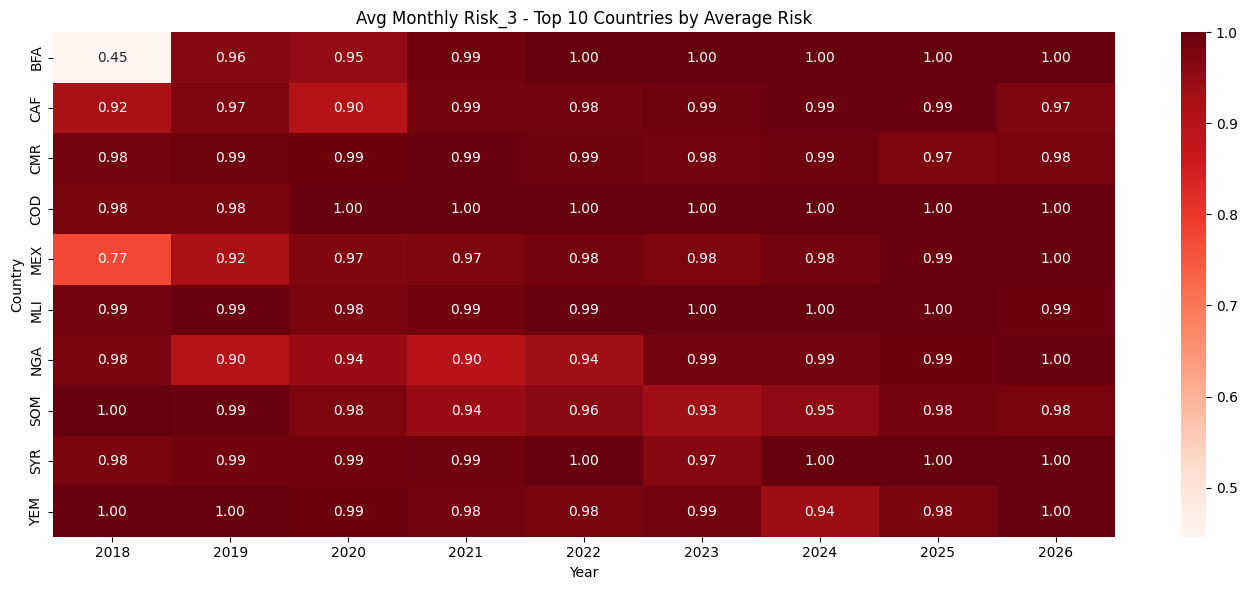

In [7]:
import seaborn as sns

df['year'] = pd.to_datetime(df['month']).dt.year

# Top 10 countries by average risk_3
top10_risk = df.groupby('iso3')['risk_3'].mean().nlargest(10).index

yearly_risk = df[df['iso3'].isin(top10_risk)].groupby(['year', 'iso3'])['risk_3'].mean().round(3)

pivot_risk = yearly_risk.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_risk, cmap='Reds', fmt='.2f', annot=True, ax=ax)
ax.set_title('Avg Monthly Risk_3 - Top 10 Countries by Average Risk')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

The heatmap shows average monthly `risk_3` for the 10 highest-risk countries. Most cells are near 1.0 throughout the entire period, reflecting that EconAI assigns near-certain conflict probability to chronic conflict contexts like Somalia, Yemen, and Congo. The most notable pattern is Burkina Faso (BFA), which starts at 0.45 in 2018 and reaches 1.0 by 2022, capturing the rapid escalation of jihadist violence in the Sahel. Mexico (MEX) shows a similar upward trend, consistent with the intensification of cartel-related violence over the period.

### Part 2: Bivariate Analysis

This section examines how EconAI risk predictions behave in relation to `allocation-eligible`. The expectation is that countries meeting the CERF criteria should show systematically higher conflict risk scores, validating the predictive signal embedded in EconAI variables.

In [8]:
# Mean risk by allocation-eligible
df.groupby('allocation-eligible')[['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12']].mean().round(3)

,risk_3,risk_12,logfat_risk_3,logfat_risk_12
allocation-eligible,,,,
0,0.141,0.207,1.006,1.548
1,0.917,0.961,6.291,7.694


The comparison of EconAI variables across allocation-eligible groups reveals a difference. Countries that are allocation-eligible show an average `risk_3` of 0.917 compared to 0.141 for non-eligible countries, a difference of more than six times. The same pattern holds for `risk_12` (0.961 vs 0.207).

For the log fatality predictions, the gap is even more pronounced. Eligible countries show a `logfat_risk_3` of 6.291, which translates to approximately 540 predicted fatalities per month in real terms (e^6.291). Non-eligible countries average 1.006 in log scale, equivalent to roughly 2.7 fatalities, a negligible level.

These results confirm that EconAI variables carry strong discriminative power between crisis and non-crisis country-months, making them valuable predictors in the early warning model. The particularly high separation in `risk_3` is especially relevant given that the target variable operates on a 2-month prediction horizon.

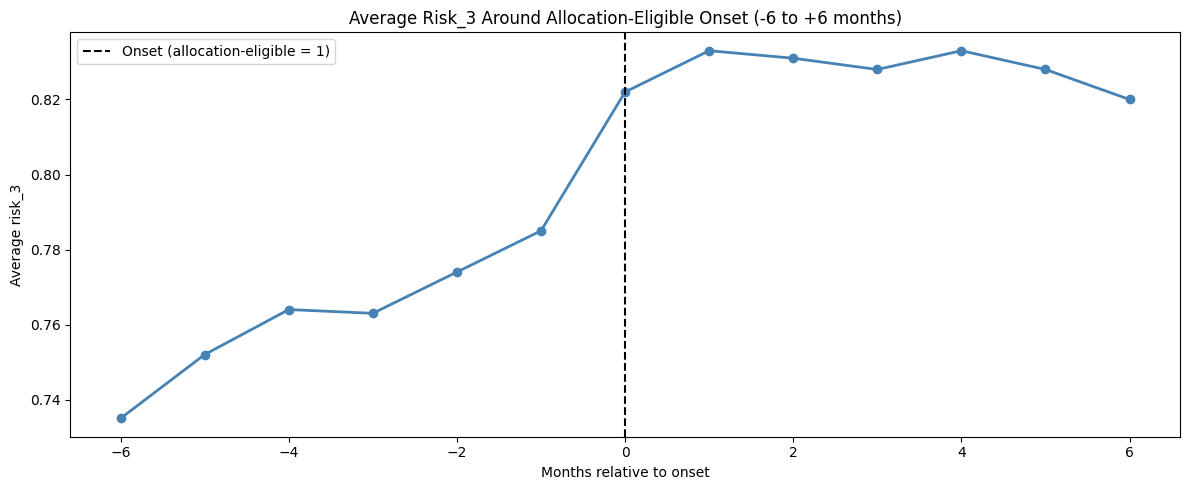

In [9]:
# Window around onset for risk_3
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['iso3', 'month'])

df['prev_eligible'] = df.groupby('iso3')['allocation-eligible'].shift(1)
onset = df[(df['allocation-eligible'] == 1) & (df['prev_eligible'] == 0)][['iso3', 'month']].copy()

windows_risk3 = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_risk3.append({'months_to_onset': t, 
                                  'risk_3': match['risk_3'].values[0]})

window_df_risk3 = pd.DataFrame(windows_risk3)
avg_risk3 = window_df_risk3.groupby('months_to_onset')['risk_3'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_risk3.index, avg_risk3.values, color='steelblue', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Risk_3 Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average risk_3')
ax.legend()
plt.tight_layout()
plt.show()

`risk_3` shows a steady upward trend starting from t-6, rising from 0.74 to 0.82 at the onset. Unlike fatalities, where the signal was concentrated in the last 2 months before onset, EconAI anticipates the crisis gradually and consistently from 6 months in advance. After the onset, risk remains elevated around 0.83, reflecting that conflict contexts persist once they begin. This earlier and smoother anticipation pattern strengthens the case for including `risk_3` as a predictor, as it provides a longer warning window than observed conflict variables like ACLED fatalities.

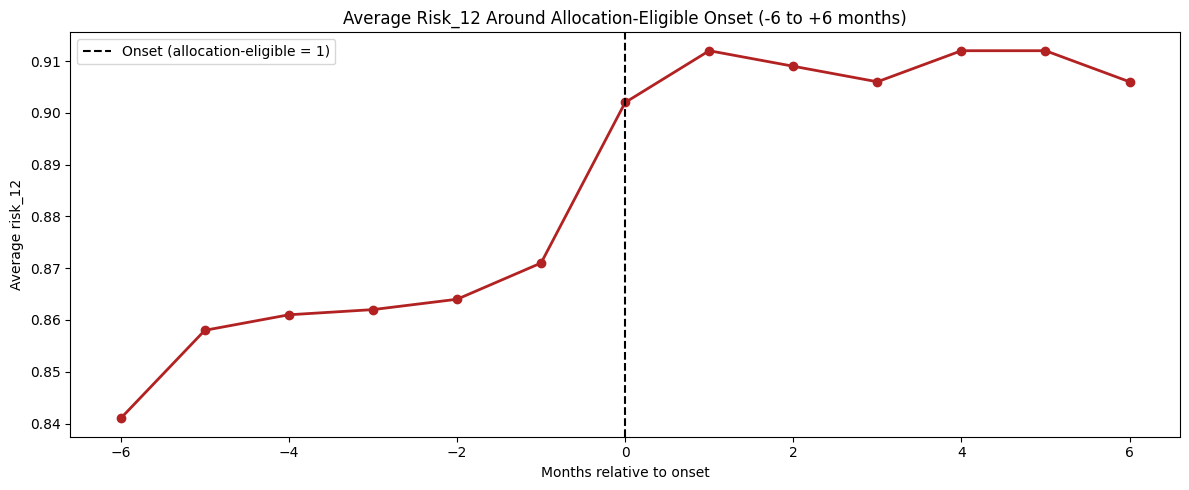

In [10]:
# Window around onset for risk_12
windows_risk12 = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_risk12.append({'months_to_onset': t,
                                   'risk_12': match['risk_12'].values[0]})

window_df_risk12 = pd.DataFrame(windows_risk12)
avg_risk12 = window_df_risk12.groupby('months_to_onset')['risk_12'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_risk12.index, avg_risk12.values, color='firebrick', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Risk_12 Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average risk_12')
ax.legend()
plt.tight_layout()
plt.show()

`risk_12` follows the same upward pattern as `risk_3`, rising from 0.84 at t-6 to 0.90 at the onset and stabilizing around 0.91 afterwards. The key difference is that baseline values are higher throughout, as the 12-month horizon naturally captures more accumulated conflict risk. Both variables confirm that EconAI anticipates allocation-eligible crises from at least 6 months in advance, making them strong early warning predictors.